In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().absolute().parent))

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import geopandas as gpd

from src.data_models.caravanify import Caravanify, CaravanifyConfig


---

In [3]:
CA_config = CaravanifyConfig(
    attributes_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CA/post_processed/attributes",
    timeseries_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CA/post_processed/timeseries/csv",
    shapefile_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CA/post_processed/shapefiles",
    human_influence_path="/Users/cooper/Desktop/CAMELS-CH/src/human_influence_index/results/human_influence_classification.csv",
    gauge_id_prefix="CA",
    use_hydroatlas_attributes=True,
    use_caravan_attributes=True,
    use_other_attributes=True,
)

CH_config = CaravanifyConfig(
    attributes_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CH/post_processed/attributes",
    timeseries_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CH/post_processed/timeseries/csv",
    shapefile_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CH/post_processed/shapefiles",
    human_influence_path="/Users/cooper/Desktop/CAMELS-CH/src/human_influence_index/results/human_influence_classification.csv",
    gauge_id_prefix="CH",
    use_hydroatlas_attributes=True,
    use_caravan_attributes=True,
    use_other_attributes=True,
)

CL_config = CaravanifyConfig(
    attributes_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CL/post_processed/attributes",
    timeseries_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CL/post_processed/timeseries/csv",
    shapefile_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CL/post_processed/shapefiles",
    human_influence_path="/Users/cooper/Desktop/CAMELS-CH/src/human_influence_index/results/human_influence_classification.csv",
    gauge_id_prefix="CL",
    use_hydroatlas_attributes=True,
    use_caravan_attributes=True,
    use_other_attributes=True,
)

USA_config = CaravanifyConfig(
    attributes_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/USA/post_processed/attributes",
    timeseries_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/USA/post_processed/timeseries/csv",
    shapefile_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/USA/post_processed/shapefiles",
    human_influence_path="/Users/cooper/Desktop/CAMELS-CH/src/human_influence_index/results/human_influence_classification.csv",
    gauge_id_prefix="USA",
    use_hydroatlas_attributes=True,
    use_caravan_attributes=True,
    use_other_attributes=True,
)

In [4]:
CA_caravan = Caravanify(CA_config)
CH_caravan = Caravanify(CH_config)
CL_caravan = Caravanify(CL_config)
USA_caravan = Caravanify(USA_config)

CA_basins = CA_caravan.get_all_gauge_ids()
CH_basins = CH_caravan.get_all_gauge_ids()
CL_basins = CL_caravan.get_all_gauge_ids()
USA_basins = USA_caravan.get_all_gauge_ids()

CA_basins, _ = CA_caravan.filter_gauge_ids_by_human_influence(CA_basins, categories=["Low", "Medium"])
CH_basins, _ = CH_caravan.filter_gauge_ids_by_human_influence(CH_basins, categories=["Low", "Medium"])
CL_basins, _ = CL_caravan.filter_gauge_ids_by_human_influence(CL_basins, categories=["Low", "Medium"])
USA_basins, _ = USA_caravan.filter_gauge_ids_by_human_influence(USA_basins, categories=["Low", "Medium"])

Original gauge_ids: 78
Filtered gauge_ids: 77
Original gauge_ids: 135
Filtered gauge_ids: 50
Original gauge_ids: 505
Filtered gauge_ids: 483
Original gauge_ids: 671
Filtered gauge_ids: 431


In [5]:
USA_shapefiles = USA_caravan.get_shapefiles()

# Filter shapefiles to only include basins in the filtered list
USA_shapefiles = USA_shapefiles[USA_shapefiles["gauge_id"].isin(USA_basins)]

CL_shapefiles = CL_caravan.get_shapefiles()

# Filter shapefiles to only include basins in the filtered list
CL_shapefiles = CL_shapefiles[CL_shapefiles["gauge_id"].isin(CL_basins)]

CH_shapefiles = CH_caravan.get_shapefiles()

# Filter shapefiles to only include basins in the filtered list
CH_shapefiles = CH_shapefiles[CH_shapefiles["gauge_id"].isin(CH_basins)]

# Concatenate the shapefiles into a single GeoDataFrame
all_shapefiles_used = pd.concat([USA_shapefiles, CL_shapefiles, CH_shapefiles], ignore_index=True)




In [6]:
all_shapefiles_used

,gauge_id,geometry
0,USA_01013500,"MULTIPOLYGON (((-68.06259 47.17901, -68.06028 ..."
1,USA_01022500,"POLYGON ((-67.97836 44.6131, -67.98141 44.6143..."
2,USA_01030500,"MULTIPOLYGON (((-68.09162 46.11477, -68.08453 ..."
3,USA_01031500,"MULTIPOLYGON (((-69.31629 45.15325, -69.32144 ..."
4,USA_01047000,"POLYGON ((-70.10847 45.21669, -70.10609 45.213..."
...,...,...
959,CH_3032,"POLYGON Z ((10.43085 47.01368 0, 10.43155 47.0..."
960,CH_3033,"MULTIPOLYGON Z (((10.42074 47.01362 0, 10.4207..."
961,CH_4002,"POLYGON Z ((8.01318 47.8717 0, 8.01316 47.8712..."
962,CH_5009,"MULTIPOLYGON Z (((6.31427 46.76394 0, 6.31427 ..."


## Get shapefiles for whole caravan

In [7]:
path_to_all_shapefiles = Path("/Users/cooper/Desktop/Caravan/CARAVAN_FULL/usr/local/google/home/kratzert/Data/Caravan-Jan25-csv/shapefiles")

# List all directories in the path
all_directories = [d for d in path_to_all_shapefiles.iterdir() if d.is_dir()]
print(f"Number of directories: {len(all_directories)}")

# Read the .shp file in each directory and concatenate the geodataframes. Find the shapefile by checking that the file name ends with ".shp"
all_geodataframes = []
for directory in all_directories:
    shapefile_path = next(directory.glob("*.shp"), None)
    if shapefile_path:
        gdf = gpd.read_file(shapefile_path)
        all_geodataframes.append(gdf)

# Concatenate all geodataframes into one
all_shapefiles_available = pd.concat(all_geodataframes, ignore_index=True)

Number of directories: 7


/Users/cooper/Desktop/CAMELS-CH/.venv/lib/python3.12/site-packages/geopandas/array.py:1638: UserWarning: CRS not set for some of the concatenation inputs. Setting output's CRS as WGS 84 (the single non-null crs provided).
  return GeometryArray(data, crs=_get_common_crs(to_concat))


In [8]:
# Combine all_shapefiles_used and all_shapefiles_available and add a column to indicate which are used and which are available
all_shapefiles_used["source"] = "used"
all_shapefiles_available["source"] = "available"

# Concatenate the two dataframes
all_shapefiles_combined = pd.concat([all_shapefiles_used, all_shapefiles_available], ignore_index=True)
all_shapefiles_combined

,gauge_id,geometry,source
0,USA_01013500,"MULTIPOLYGON (((-68.06259 47.17901, -68.06028 ...",used
1,USA_01022500,"POLYGON ((-67.97836 44.6131, -67.98141 44.6143...",used
2,USA_01030500,"MULTIPOLYGON (((-68.09162 46.11477, -68.08453 ...",used
3,USA_01031500,"MULTIPOLYGON (((-69.31629 45.15325, -69.32144 ...",used
4,USA_01047000,"POLYGON ((-70.10847 45.21669, -70.10609 45.213...",used
...,...,...,...
16919,camels_14309500,"POLYGON ((-123.81322 42.89103, -123.81128 42.8...",available
16920,camels_14316700,"POLYGON ((-122.49936 43.47688, -122.49127 43.4...",available
16921,camels_14325000,"POLYGON ((-124.07751 42.89822, -124.06406 42.8...",available
16922,camels_14362250,"POLYGON ((-123.15128 42.19624, -123.14891 42.1...",available


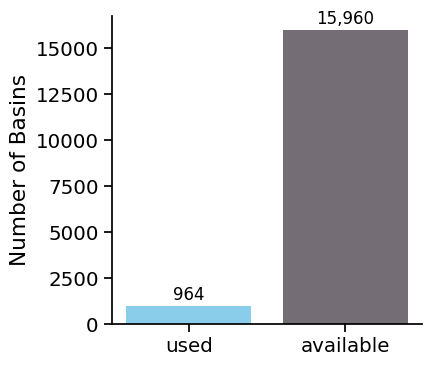

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context("notebook", font_scale=1.3)

# Data for the bar chart
categories = ['used', 'available']
values = [964, 15960]

# Create the bar chart
plt.figure(figsize=(4, 4))
bars = plt.bar(categories, values, color=['#8ACDEA', '#746D75'])

# Add the numbers on top of the bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01*max(values),
             f'{height:,}',
             ha='center', va='bottom', fontsize=12)

# Labeling the axes and the chart title
plt.xlabel('')
plt.ylabel('Number of Basins')

# Display the plot
sns.despine()
path_to_save = "/Users/cooper/Desktop/CAMELS-CH/images/SDC/used_available_basins.png"
plt.savefig(path_to_save, dpi=300, bbox_inches='tight')

plt.show()


## Make a map 

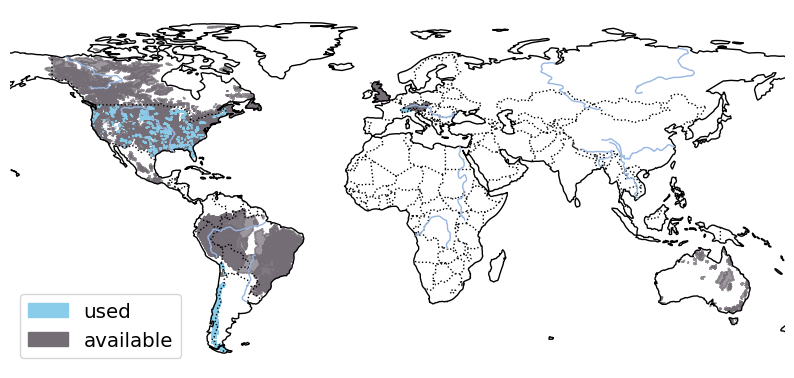

In [10]:
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import Patch

# Define your desired color mapping
source_colors = {
    "used": "#8ACDEA",      # Light blue
    "available": "#746D75", # Grayish
}

# Create a figure and Cartopy axes with the PlateCarree projection
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={"projection": ccrs.PlateCarree()})

# Add base map features
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.add_feature(cfeature.LAND, facecolor='none')  # or adjust as needed
ax.add_feature(cfeature.OCEAN, facecolor='none')
ax.add_feature(cfeature.LAKES, facecolor='none')
ax.add_feature(cfeature.RIVERS, facecolor='none')

# Plot available features first
all_shapefiles_available.plot(
    ax=ax,
    facecolor=source_colors["available"],
    edgecolor="#746D75",
    transform=ccrs.PlateCarree(),
    alpha=0.7
)

# Then plot the used features on top
all_shapefiles_used.plot(
    ax=ax,
    facecolor=source_colors["used"],
    edgecolor="#8ACDEA",
    transform=ccrs.PlateCarree(),
    alpha=0.9
)

# Create a legend for the two source types
legend_elements = [
    Patch(facecolor=source_colors["used"], edgecolor="#8ACDEA", label="used"),
    Patch(facecolor=source_colors["available"], edgecolor="#746D75", label="available")
]
ax.legend(handles=legend_elements, loc="lower left")

# Optional: Remove spines for a cleaner look
for spine in ax.spines.values():
    spine.set_visible(False)

# Set a title and display the plot
# plt.title("Shapefile Map: 'used' Over 'available'")
path_to_save = "/Users/cooper/Desktop/CAMELS-CH/images/Maps/used_available_basins_map.png"
plt.savefig(path_to_save, dpi=300, bbox_inches='tight')
plt.show()
